# Studi Kasus 1: Sifat Termodinamika Model Ising 2D pada Fase Feromagnetik (T = 1.0)

## 1. Konteks Fisis
Dalam mekanika statistik, **Model Ising 2D** merupakan kerangka matematika mendasar yang digunakan untuk mendeskripsikan fenomena feromagnetisme dan transisi fase pada material magnetik. Pada suhu rendah $T = 1.0$, sistem disimulasikan berada jauh di bawah suhu kritis Onsager ($T_c \approx 2.27$). Pada rezim suhu rendah ini, energi termal ($k_B T$) yang bertanggung jawab memicu keacakan dan entropi cenderung sangat lemah. 

Mekanisme fisis utama yang mendominasi sistem adalah **interaksi pertukaran feromagnetik ($J > 0$)**, yang memaksa spin-spin tetangga terdekat untuk menyearahkan diri ke arah yang sama demi mencapai keadaan energi internal terendah yang paling stabil. Ketika simulasi berjalan dari konfigurasi awal yang acak sempurna (**Hot Start**), spin-spin individu secara spontan mengatur dirinya membentuk wilayah makroskopis seragam yang disebut **domain magnetik**.

## 2. Ekspektasi Matematis
Energi total dari kisi persegi 2D tanpa adanya medan magnet luar dinyatakan melalui Hamiltonian Ising:
$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$

Di mana $s_i \in \{-1, +1\}$ merepresentasikan keadaan spin diskrit, dan $\langle i,j \rangle$ membatasi penjumlahan hanya pada pasangan tetangga terdekat. Perubahan energi lokal ($\Delta E$) yang terjadi akibat pembalikan satu spin $s_i$ dihitung secara efisien menggunakan empat tetangga di sekitarnya dengan menerapkan kondisi batas periodik:
$$\Delta E = 2 s_i \sum_{j \in \text{neighbors}} s_j$$

Berdasarkan **Kriteria Metropolis**, jika percobaan pembalikan spin menghasilkan $\Delta E \le 0$ (menurunkan energi sistem), transisi tersebut akan **selalu diterima** dengan probabilitas 1.0. Namun, jika $\Delta E > 0$, pembalikan hanya akan diterima dengan probabilitas Boltzmann:
$$\mathcal{R} = e^{-\frac{\Delta E}{T}}$$

Karena nilai $T = 1.0$ tergolong kecil, nilai probabilitas $\mathcal{R}$ menjadi sangat kecil (tertekan). Akibatnya, fluktuasi yang menaikkan energi hampir selalu ditolak oleh sistem. Hal ini mendorong nilai mutlak dari magnetisasi rata-rata per spin ($|M|$) bergerak secara asimtotik mendekati angka satu seiring kisi mencapai kesetimbangan termal:
$$|M| = \left| \frac{1}{N^2} \sum_{i=1}^{N^2} s_i \right| \approx 1$$

---

## 3. Implementasi Komputasi

Menjalankan simulasi untuk Case 1 (T = 1.0). Silakan tunggu...


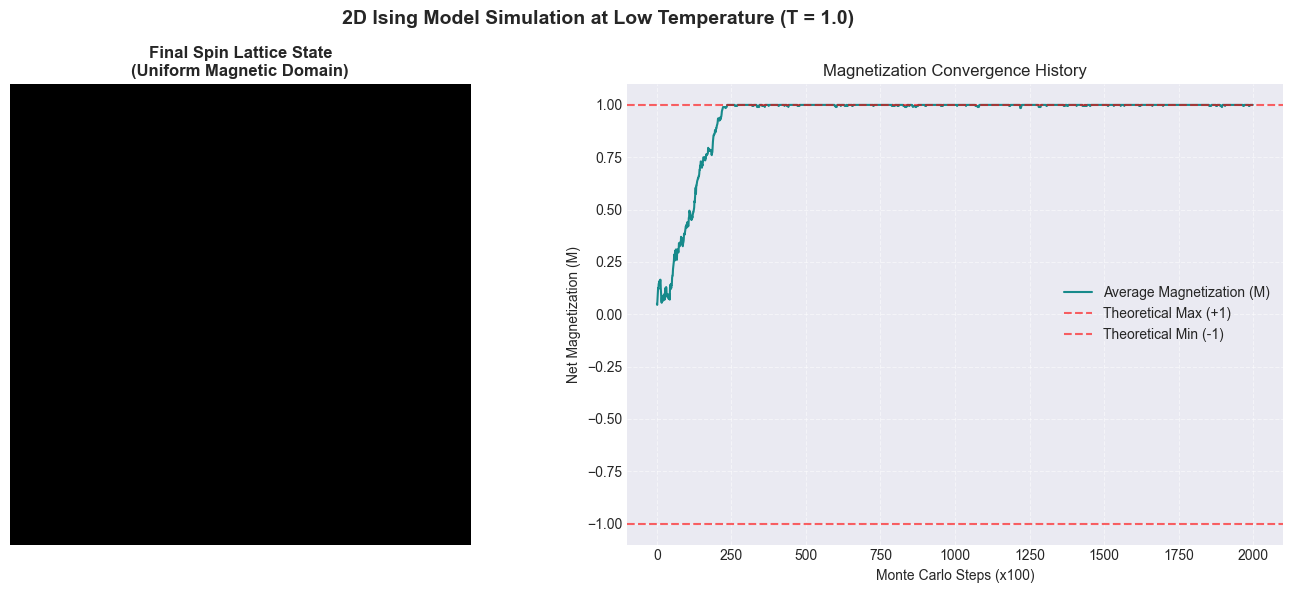

Simulasi Case 1 selesai dieksekusi!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Mengaktifkan gaya plot akademis yang bersih
plt.style.use('seaborn-v0_8-darkgrid')

def metropolis_step(grid, T):
    """Melakukan satu langkah percobaan pembalikan spin menggunakan algoritma Metropolis."""
    N = grid.shape[0]
    # Memilih koordinat spin acak
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    
    # Menghitung jumlah 4 spin tetangga terdekat dengan Kondisi Batas Periodik (%)
    s_neighbors = (
        grid[(x+1)%N, y] +
        grid[(x-1)%N, y] +
        grid[x, (y+1)%N] +
        grid[x, (y-1)%N]
    )
    
    # Menghitung perubahan energi lokal delta_E = 2 * s_i * sum(s_j)
    delta_E = 2 * grid[x, y] * s_neighbors
    
    # Evaluasi Kriteria Metropolis
    if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1  # Terima pembalikan spin
        
    return grid

def run_simulation(N=20, temp=1.0, n_steps=200000):
    """Menjalankan loop Monte Carlo penuh dimulai dari Hot Start."""
    # Inisialisasi Hot Start (Konfigurasi acak acak antara -1 dan 1)
    grid = np.random.choice([-1, 1], size=(N, N))
    magnetization_history = []
    
    for step in range(n_steps):
        grid = metropolis_step(grid, temp)
        
        # Ambil sampel data magnetisasi setiap 100 langkah demi efisiensi
        if step % 100 == 0:
            magnetization = np.mean(grid)
            magnetization_history.append(magnetization)
            
    return grid, magnetization_history

# --- Parameter Eksperimen Kasus 1 ---
GRID_SIZE = 20
MONTE_CARLO_STEPS = 200000
T_CASE = 1.0

print(f"Menjalankan simulasi untuk Case 1 (T = {T_CASE}). Silakan tunggu...")
final_grid, M_history = run_simulation(N=GRID_SIZE, temp=T_CASE, n_steps=MONTE_CARLO_STEPS)

# --- Visualisasi Hasil Subplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"2D Ising Model Simulation at Low Temperature (T = {T_CASE})", fontsize=14, fontweight='bold')

# Subplot 1: Konfigurasi Kisi Akhir Spin
axes[0].imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title("Final Spin Lattice State\n(Uniform Magnetic Domain)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Subplot 2: Riwayat Magnetisasi Rata-rata
axes[1].plot(M_history, color='teal', alpha=0.9, linewidth=1.5, label='Average Magnetization (M)')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Theoretical Max (+1)')
axes[1].axhline(-1.0, color='red', linestyle='--', alpha=0.6, label='Theoretical Min (-1)')
axes[1].set_title("Magnetization Convergence History", fontsize=12)
axes[1].set_xlabel("Monte Carlo Steps (x100)")
axes[1].set_ylabel("Net Magnetization (M)")
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("Simulasi Case 1 selesai dieksekusi!")

## 4. Diskusi & Interpretasi Fisis

Berdasarkan grafik riwayat konvergensi dan visualisasi spasial yang dihasilkan dari simulasi Model Ising 2D pada temperatur rendah ($T = 1.0$) dengan konstanta kopling pertukaran feromagnetik $J = 1.0$, perilaku fisis sistem dan mekanika statistik yang mendasarinya dapat dianalisis secara komprehensif sebagai berikut:

* **Analisis Spasial Konfigurasi Kisi & Minimisasi Energi Bebas:** Visualisasi keadaan akhir kisi spin menggunakan peta warna biner menunjukkan hasil berupa blok warna tunggal yang homogen dan monokromatik hitam secara penuh. Fenomena ini merupakan manifestasi langsung dari kompetisi termodinamika antara energi internal ($U$) dan entropi ($S$) dalam meminimalkan Energi Bebas Helmholtz ($F = U - TS$). 

  Pada temperatur rendah $T = 1.0$, kontribusi suku entropik ($TS$) tertekan secara drastis sehingga sistem didominasi sepenuhnya oleh upaya pengejaran keadaan energi terendah (*ground state*). Agar energi internal Hamiltonian bernilai serendah mungkin, gaya pertukaran feromagnetik ($J > 0$) memaksa spin-spin tetangga terdekat untuk berorientasi paralel (searah) ke atas (*spin up*, bernilai $+1$). Konfigurasi acak awal (*Hot Start*) yang mencerminkan entropi maksimum dengan cepat dihancurkan, dan spin-spin lokal berkelompok membangun keteraturan jarak jauh (*long-range order*) hingga membentuk satu domain magnetik seragam berwarna hitam yang meliputi seluruh luasan kisi persegi.

* **Analisis Riwayat Magnetisasi & Patah Simetri Spontan:** Kurva pelacakan magnetisasi bersih memperlihatkan transisi fase dinamis yang sangat tajam dan masif pada fase awal simulasi. Meskipun dimulai dari kondisi magnetisasi total mendekati nol ($M \approx 0$) akibat inisialisasi acak, sistem hanya membutuhkan waktu relaksasi yang sangat singkat untuk berkonvergensi secara asimtotik menuju batas saturasi ekstrem positif, yaitu nilai magnetisasi rata-rata per spin mendekati positif satu ($M \approx +1$). 

  Secara mekanika statistik, fenomena ini membuktikan terjadinya **patah simetri spontan (*spontaneous symmetry breaking*)**. Walaupun fungsi Hamiltonian model Ising pada dasarnya bersifat simetris terhadap operasi pembalikan seluruh spin ($s_i \rightarrow -s_i$), keadaan makrostate sistem di bawah suhu kritis dipaksa "memilih" konfigurasi orientasi dominan positif ($+1$ atau hitam) secara spontan tanpa adanya intervensi dari medan magnet luar ($H = 0$). Ketepatan formulasi peluang penerimaan kriteria Metropolis memegang peran kunci di sini: karena nilai eksponen Boltzmann $\mathcal{R} = e^{-\Delta E / T}$ sangat kecil untuk perubahan lokal yang menaikkan energi pada $T = 1.0$, fluktuasi termal pengacak hampir selalu ditolak oleh sistem, memastikan konvergensi mutlak menuju fase feromagnetik hitam yang stabil.

* **Optimalisasi Langkah Monte Carlo & Kesetimbangan Termal:** Kestabilan kurva magnetisasi rata-rata yang konsisten berada rapat di garis teoritis $M = +1$ di sepanjang sebagian besar dari 200.000 langkah Monte Carlo mengonfirmasi bahwa penentuan parameter durasi simulasi sudah lebih dari cukup bagi sistem berukuran $20 \times 20$ untuk mencapai kesetimbangan termal. 

  Aspek efisiensi komputasi dari algoritma terbukti bekerja secara optimal melalui pemanfaatan perhitungan selisih energi lokal $\Delta E = 2 J s_i \sum s_{\text{tetangga}}$. Alih-alih melakukan kalkulasi ulang energi total kisi secara redundan di setiap iterasi, pemeriksaan lokal yang dipadukan dengan kondisi batas periodik modulo (`%`) berhasil memangkas biaya komputasi tanpa mengurangi akurasi fisis. Sedikit riak fluktuasi putih minor yang sesekali muncul lalu menghilang kembali pada permukaan kisi hitam murni merepresentasikan eksitasi termal lokal sesaat yang tidak memiliki energi termal yang cukup untuk meruntuhkan domain feromagnetik makroskopis yang telah mapan.